
    __________________________________________________________________________
       __  ___ ___    ____  _____
      /  |/  //   |  / __ \/ ___/
     / /|_/ // /| | / /_/ /\__ \ 
    / /  / // ___ |/ _, _/___/ / 
   /_/  /_//_/  |_/_/ |_|/____/  
                                 
    MODELING ANALYSIS RISK SCORE 
    __________________________________________________________________________
    Version: 0.0.1 | Copyright (c) 2026 Christian Li
    High-performance Risk Modeling Toolkit powered by Polars
    __________________________________________________________________________

⏳ Generating Data (Normal + Missing + Special)...
✅ Data Ready! Train Size: 10000

🛠️ Training Binner with Special Values...
[MARS] 2026-01-19 03:30:18 - INFO - ⏱️ [MarsNativeBinner._fit_impl] finished in 0.0035s
✅ Binning Done!
Age Cuts: [-inf, 30.838196428515445, 33.83316355618233, 36.292609573598114, 39.214156223642156, inf]

📡 Running Monitor...
[MARS] 2026-01-19 03:30:18 - INFO - ⚙️ [Monitor] Establis

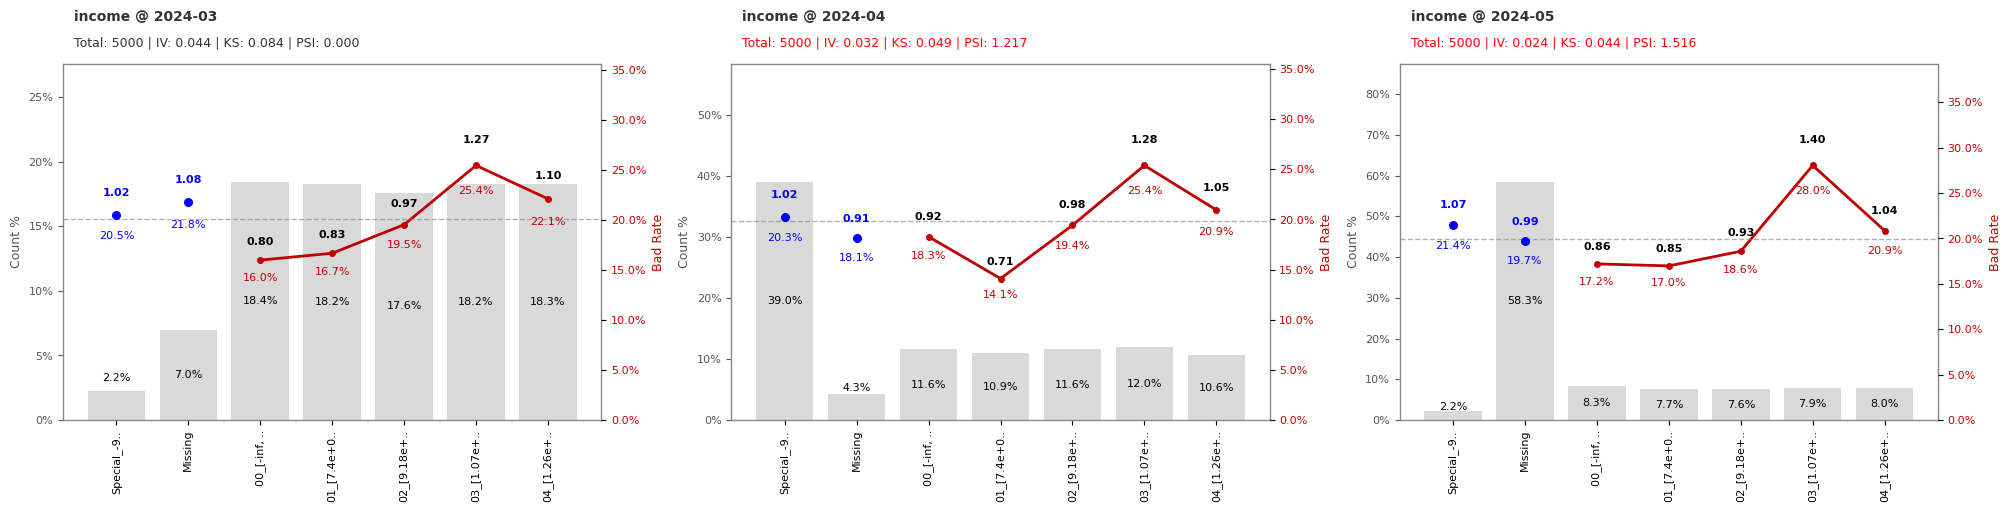

In [ ]:
import pandas as pd
import numpy as np
import polars as pl
from datetime import datetime, timedelta
from mars.feature.binner import MarsNativeBinner
from mars.feature.monitor import MarsFeatureMonitor
from mars.utils.

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
from typing import Optional, List, Tuple

class MarsVisualizer:
    """
    [Mars 可视化引擎 - Standard Box Style]
    标准的边框封闭样式，线条粗细与坐标轴一致。
    """

    @staticmethod
    def plot_binning_grid(
        detail_df: pd.DataFrame, 
        feature_col: str = "feature",
        group_col: str = "_grp_month", 
        bin_col: str = "bin_label",
        features: Optional[List[str]] = None,
        groups: Optional[List[str]] = None,
        figsize: Tuple[int, int] = (20, 6)
    ):
        # 1. 数据过滤
        if features: detail_df = detail_df[detail_df[feature_col].isin(features)]
        if groups: detail_df = detail_df[detail_df[group_col].isin(groups)]
            
        uniq_feats = detail_df[feature_col].unique()
        uniq_grps = detail_df[group_col].unique()
        
        n_rows, n_cols = len(uniq_feats), len(uniq_grps)
        if n_rows == 0: return

        # 动态调整高度
        fig, axes = plt.subplots(
            n_rows, n_cols, 
            figsize=(figsize[0], figsize[1] * n_rows), 
            constrained_layout=True
        )
        
        if n_rows == 1 and n_cols == 1: axes = np.array([[axes]])
        elif n_rows == 1: axes = axes.reshape(1, -1)
        elif n_cols == 1: axes = axes.reshape(-1, 1)

        # 循环绘图
        for i, feat in enumerate(uniq_feats):
            for j, grp in enumerate(uniq_grps):
                ax = axes[i, j]
                
                # 数据切片
                data = detail_df[
                    (detail_df[feature_col] == feat) & 
                    (detail_df[group_col] == grp)
                ].copy()
                
                if data.empty:
                    ax.axis('off'); continue
                
                if 'bin_idx' in data.columns: data = data.sort_values('bin_idx')
                
                x = np.arange(len(data))
                pct_actual = data['pct_actual'].fillna(0)
                bad_rate = data['bin_bad_rate'].fillna(0)
                lifts = data['lift'].fillna(0)
                grp_bad_rate = data['grp_bad_rate'].iloc[0]
                
                is_special = data['bin_idx'] < 0
                special_indices = x[is_special]
                normal_indices = x[~is_special]
                
                # ==========================================================
                # Layer 1: 灰色柱状图 (Count %) - 左轴
                # ==========================================================
                bars = ax.bar(x, pct_actual, color='#D9D9D9', label='Count %', width=0.8, align='center')
                
                # 左轴设置
                y_max_bar = pct_actual.max()
                ax.set_ylim(0, y_max_bar * 1.5) 
                ax.set_ylabel("Count %", fontsize=9, color='#555555')
                ax.tick_params(axis='y', colors='#555555', labelsize=8)
                ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
                
                # [核心修改] 设置边框 (Spines)
                # 开启 Top 和 Right，并设置统一颜色，形成闭环框
                for spine in ['top', 'bottom', 'left', 'right']:
                    ax.spines[spine].set_visible(True)
                    ax.spines[spine].set_color('#888888') # 统一深灰色
                    ax.spines[spine].set_linewidth(1.0)   # 统一线条粗细

                # 柱内标注
                for bar, pct in zip(bars, pct_actual):
                    if pct > 0:
                        height = bar.get_height()
                        y_pos = height / 2 if height > 0.05 else height + 0.01
                        ax.text(bar.get_x() + bar.get_width()/2., y_pos, f'{pct:.1%}', 
                                ha='center', va='center', fontsize=8, color='black')

                # ==========================================================
                # Layer 2: 红色折线图 (Bad Rate) - 右轴
                # ==========================================================
                ax2 = ax.twinx()
                
                if len(normal_indices) > 0:
                    ax2.plot(normal_indices, bad_rate.iloc[normal_indices], color='#C00000', 
                             marker='o', linewidth=2, markersize=4, label='Bad Rate')
                    
                    for idx in normal_indices:
                        br = bad_rate.iloc[idx]
                        lift = lifts.iloc[idx]
                        if br > 0:
                            ax2.text(idx, br * 1.08, f'{lift:.2f}', ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')
                            ax2.text(idx, br * 0.92, f'{br:.1%}', ha='center', va='top', fontsize=8, color='#C00000')

                if len(special_indices) > 0:
                    ax2.scatter(special_indices, bad_rate.iloc[special_indices], color='blue', s=30, zorder=5)
                    for idx in special_indices:
                        br = bad_rate.iloc[idx]
                        lift = lifts.iloc[idx]
                        ax2.text(idx, br * 1.08, f'{lift:.2f}', ha='center', va='bottom', fontsize=8, color='blue', fontweight='bold')
                        ax2.text(idx, br * 0.92, f'{br:.1%}', ha='center', va='top', fontsize=8, color='blue')

                # 右轴设置
                br_max = bad_rate.max() if bad_rate.max() > 0 else 0.1
                ax2.set_ylim(0, br_max * 1.4)
                ax2.set_ylabel("Bad Rate", color='#C00000', fontsize=9)
                ax2.tick_params(axis='y', labelcolor='#C00000', labelsize=8)
                ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
                
                # [核心修改] 隐藏 ax2 的所有边框，完全复用 ax1 的边框
                # 这样可以避免双重边框导致的线条错位或变粗
                for spine in ax2.spines.values():
                    spine.set_visible(False)

                # ==========================================================
                # Layer 3: 辅助线 & Title
                # ==========================================================
                ax2.axhline(grp_bad_rate, color='gray', linestyle='--', linewidth=1, alpha=0.6)

                # X 轴
                ax.set_xticks(x)
                labels = [str(l)[:10] + '..' if len(str(l))>10 else str(l) for l in data[bin_col]]
                ax.set_xticklabels(labels, rotation=90, fontsize=8)

                # 标题
                iv = data['IV'].iloc[0] if 'IV' in data.columns else 0
                ks = data['KS'].iloc[0] if 'KS' in data.columns else 0
                psi = data['PSI'].iloc[0] if 'PSI' in data.columns else 0
                count = data['n_bin'].sum()
                
                # 调整标题位置，稍微下移一点，确保在框内或框上边缘
                ax.text(0.02, 1.12, f"{feat} @ {grp}", transform=ax.transAxes, 
                        fontsize=10, fontweight='bold', color='#333333', ha='left')
                
                metrics_text = f"Total: {count} | IV: {iv:.3f} | KS: {ks:.3f} | PSI: {psi:.3f}"
                t_color = 'red' if psi > 0.1 else '#333333'
                
                ax.text(0.02, 1.04, metrics_text, transform=ax.transAxes, 
                        fontsize=9, color=t_color, ha='left', va='bottom')

        plt.show()

import pandas as pd
import numpy as np
import polars as pl
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Ensure Mars classes are imported correctly in your environment
# from mars.feature.binning_ import MarsBinner
# from mars.feature.monitor import MarsFeatureMonitor
# from mars.monitor.visualizer import MarsVisualizer

# ==============================================================================
# 1. 制造模拟数据 (Synthetic Data Generation)
# ==============================================================================
def generate_mock_data(n_rows=10000, start_date='2024-01-01', days=30, drift_factor=0.0, missing_rate=0.0, special_rate=0.0):
    """
    生成模拟风控数据，支持缺失值和特殊值注入。
    
    Parameters:
    ----------
    drift_factor: 漂移因子。
    missing_rate: 缺失率 (注入 np.nan)。
    special_rate: 特殊值率 (注入 -999)。
    """
    np.random.seed(42 + int(drift_factor * 100))
    
    dates = [datetime.strptime(start_date, "%Y-%m-%d") + timedelta(days=np.random.randint(0, days)) for _ in range(n_rows)]
    
    # 基础特征生成
    age = np.random.normal(35 - (10 * drift_factor), 5, n_rows).astype(float)
    age = np.clip(age, 18, 60)
    
    income = np.random.normal(10000 - (2000 * drift_factor), 3000, n_rows)
    income = np.clip(income, 3000, 50000)
    
    score = np.random.beta(2, 5, n_rows) * 100
    
    # 注入缺失值 (Missing)
    if missing_rate > 0:
        mask_age_miss = np.random.rand(n_rows) < missing_rate
        age[mask_age_miss] = np.nan
        
        mask_inc_miss = np.random.rand(n_rows) < (missing_rate * 1.5)
        income[mask_inc_miss] = np.nan

    # 注入特殊值 (Special Value: -999)
    # 注意：为了避免覆盖掉刚生成的 NaN，我们只在非 NaN 的数据上覆盖特殊值，或者简单覆盖
    if special_rate > 0:
        # 简单起见，重新生成随机掩码，可能会覆盖掉一部分 NaN，模拟真实世界的混乱
        mask_age_spec = np.random.rand(n_rows) < special_rate
        age[mask_age_spec] = -999
        
        mask_inc_spec = np.random.rand(n_rows) < special_rate
        income[mask_inc_spec] = -999

    # 生成 Target (处理 NaN 和 Special)
    # 在计算 Logits 时，我们需要把 NaN 和 -999 替换为某种中性值，以免报错
    age_fill = np.where(np.isnan(age) | (age == -999), 35, age)
    income_fill = np.where(np.isnan(income) | (income == -999), 10000, income)
    
    logits = -2 + (35 - age_fill)/10 * 0.5 + (10000 - income_fill)/10000 * 0.8 + (50 - score)/50 * 1.2
    if drift_factor > 0: logits += 0.5
        
    prob = 1 / (1 + np.exp(-logits))
    target = np.random.binomial(1, prob)
    
    return pd.DataFrame({
        'apply_date': dates,
        'age': age,
        'income': income,
        'risk_score': score,
        'target': target
    })

print("⏳ Generating Data (Normal + Missing + Special)...")

# A. 训练集: 少量缺失，少量特殊值
df_train = pd.concat([
    generate_mock_data(n_rows=5000, start_date='2024-01-01', days=31, missing_rate=0.05, special_rate=0.02),
    generate_mock_data(n_rows=5000, start_date='2024-02-01', days=29, missing_rate=0.05, special_rate=0.02)
])

# B. 监控集:
# - 3月: 正常
# - 4月: 特殊值 (-999) 暴增 (例如前端采集规则变了，默认值全填-999)
# - 5月: 缺失值 (NaN) 暴增
df_monitor = pd.concat([
    generate_mock_data(n_rows=5000, start_date='2024-03-01', days=31, missing_rate=0.05, special_rate=0.02),
    generate_mock_data(n_rows=5000, start_date='2024-04-01', days=30, missing_rate=0.05, special_rate=0.40), # 🚨 Special Spike
    generate_mock_data(n_rows=5000, start_date='2024-05-01', days=31, missing_rate=0.40, special_rate=0.02)  # 🚨 Missing Spike
])

print(f"✅ Data Ready! Train Size: {len(df_train)}")


# ==============================================================================
# 2. 特征分箱 (Binning Phase)
# ==============================================================================
print("\n🛠️ Training Binner with Special Values...")

# 关键点：显式告诉 Binner 哪些是特殊值
binner = MarsNativeBinner(
    method='quantile', 
    n_bins=5, 
    features=['age', 'income', 'risk_score'],
    missing_values=[np.nan],  # 归为 Missing 组
    special_values=[-999]     # 归为 Special 组
)
binner.fit(df_train, df_train['target'])

print("✅ Binning Done!")
# 查看一下 mapping，应该能看到 Special_-999 的箱子
print(f"Age Cuts: {binner.bin_cuts_.get('age')}")


# ==============================================================================
# 3. 特征监控 (Monitoring Phase)
# ==============================================================================
print("\n📡 Running Monitor...")

monitor = MarsFeatureMonitor(binner)
monitor.fit(df_train, df_train['target'])

report = monitor.calculate(
    data=df_monitor,
    target="target",
    dt_col="apply_date",
    period="month"
)

print("✅ Calculation Done!")
print("\n📊 L1 Summary Table:")
print(report.summary_table[['_grp_month', 'feature', 'count', 'bad_rate', 'PSI']].head(10))


# ==============================================================================
# 4. 可视化 (Visualization Phase)
# ==============================================================================
print("\n🎨 Plotting Charts...")

# 找出 PSI 最大的特征
worst_feature = (
    report.summary_table
    .groupby("feature")["PSI"].max()
    .sort_values(ascending=False)
    .index[0]
)
print(f"🚨 Plotting feature: {worst_feature}")

MarsVisualizer.plot_binning_grid(
    report.detail_table,
    feature_col="feature",
    group_col="_grp_month",
    bin_col="bin_label",
    features=[worst_feature], 
    figsize=(20, 5)
)

In [3]:
report.summary_table

,_grp_month,feature,count,bad_rate,PSI,IV,KS
0,2024-03,age,5000,0.2008,0.000022,0.089773,0.124003
1,2024-03,income,5000,0.2008,0.000208,0.044370,0.083923
2,2024-03,risk_score,5000,0.2008,0.000004,0.157008,0.165755
3,2024-04,age,5000,0.1986,1.278869,0.018883,0.057954
4,2024-04,income,5000,0.1986,1.217226,0.031944,0.048732
5,2024-04,risk_score,5000,0.1986,0.003345,0.182770,0.186321
6,2024-05,age,5000,0.1998,0.913252,0.077913,0.096870
7,2024-05,income,5000,0.1998,1.515834,0.024484,0.044232
8,2024-05,risk_score,5000,0.1998,0.000004,0.162079,0.166374
